## Similitud - Firmas MinHash

Se calcula una firma MinHash por proceso a partir de la columna `shingles` (k=5) de `data/final/`

- Hashes `(a·x + b) mod p` como en lab3.1/3.2; cada shingle se codifica con `xxhash64` (nativo en Spark) en vez de `blake2b`

- La firma de `T` enteros reemplaza al conjunto de shingles para estimar Jaccard

### Imports

In [1]:
import os, socket, sys, time, shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window, functions as F

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})
pd.set_option("display.max_colwidth", 80); pd.set_option("display.width", 200)

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
final_dir = proyecto / "data" / "final"
out_dir = proyecto / "02_Similitud" / "temp" / "a_minhash"
out_dir.mkdir(parents=True, exist_ok=True)
firmas_dir = out_dir / "firmas"

- Funciones

Parámetros y funciones compartidas de `02_Similitud/funciones.ipynb`

In [3]:
ruta_funciones = str(proyecto / "02_Similitud" / "funciones.ipynb")
%run $ruta_funciones

- Figuras y tablas

In [4]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()


def guardar_tabla(df, nombre):
    # parquet para el siguiente notebook + json para la página web
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()


def dirs_salida(out_dir):
    fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
    for d in (fig_dir, tab_dir, web_dir):
        d.mkdir(parents=True, exist_ok=True)
    return fig_dir, tab_dir, web_dir


fig_dir, tab_dir, web_dir = dirs_salida(out_dir)

- Spark

In [5]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("similitud-firmas")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "4g"))     # 4g (vs 2g en 05): firmas/vectores y joins por pares pesan más que canastas
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "4g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.sql.autoBroadcastJoinThreshold", "-1")                                   # ~231k filas: 24 tareas bastan, las 200 por defecto quedarían casi vacías
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [ ]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()
print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

---
### 1. Carga de data

Spark lee las carpetas `anio=*/mes=*` de `data/final/` como columnas de partición; se filtra por `ANIOS` y se revisan los shingles

In [7]:
assert final_dir.exists(), f"No se encuentra {final_dir}; corre 01_EDA_KDD/KDD/a_transformaciones.ipynb"
print(f"Particiones en disco: {len(list(final_dir.glob('anio=*/mes=*')))} carpetas anio=/mes=")

procesos = spark.read.parquet(str(final_dir)).select(*COLS_SIMILITUD).where(F.col("anio").isin(ANIOS))
N = procesos.count()
print(f"Procesos: {N:,}")

procesos.groupBy("anio").count().orderBy("anio").show()
(procesos.select(F.size("shingles").alias("n"))
         .select(F.min("n").alias("min_shingles"), F.expr("percentile_approx(n, 0.5)").alias("mediana"),
                 F.max("n").alias("max"), F.sum((F.col("n") == 0).cast("int")).alias("vacios")).show())
procesos.select("ocid", "entidad", F.slice("shingles", 1, 6).alias("shingles (6 primeros)")).show(3, truncate=60)

Particiones en disco: 36 carpetas anio=/mes=


Procesos: 235,954


+----+-----+
|anio|count|
+----+-----+
|2023|76390|
|2024|80263|
|2025|79301|
+----+-----+



+------------+-------+----+------+
|min_shingles|mediana| max|vacios|
+------------+-------+----+------+
|           9|    183|4895|     0|
+------------+-------+----+------+

+---------------------------+-----------------------------------+------------------------------------------+
|                       ocid|                            entidad|                     shingles (6 primeros)|
+---------------------------+-----------------------------------+------------------------------------------+
|ocds-dgv273-seacev3-1085359|            PETROLEOS DEL PERU S.A.|[adqui, dquis, quisi, uisic, isici, sicio]|
|ocds-dgv273-seacev3-1090383|MUNICIPALIDAD DISTRITAL DE LIVITACA|[contr, ontra, ntrat, trata, ratac, ataci]|
|ocds-dgv273-seacev3-1092010|            ZONA ARQUEOLOGICA CARAL|[contr, ontra, ntrat, trata, ratac, ataci]|
+---------------------------+-----------------------------------+------------------------------------------+
only showing top 3 rows



### 2. Representación como conjuntos

- Cada proceso es un **conjunto de shingles de 5 caracteres** sobre `texto` (descripción + ítems, normalizado en el KDD)

- Se compara con shingles de 3 y 7 caracteres y con el conjunto de palabras (`tokens`), en un mes de referencia y con dos tipos de pares:
  - **al azar**: no deberían parecerse; mide similitud falsa
  - **misma entidad a ≤ `VENTANA_DIAS` días**: los candidatos de P2; mide cuántos casi-duplicados se detectan sin ser texto idéntico

In [8]:
MES_REP = (2024, 6)        # mismo mes de referencia que b_lsh

def shingles_k(k):
    return (F.when(F.length("texto") >= k,
                   F.array_distinct(F.expr(f"transform(sequence(1, length(texto) - {k} + 1), i -> substring(texto, i, {k}))")))
             .otherwise(F.array("texto")))

# k=5 es el del KDD; k=3 y k=7 a cada lado, y las palabras que usa ANN
REPS = {"k=3": shingles_k(3), "k=5": F.col("shingles"), "k=7": shingles_k(7), "palabras": F.col("tokens")}

tokens_df = spark.read.parquet(str(final_dir)).select("ocid", "tokens")
mes_rep = (procesos.where((F.col("anio") == MES_REP[0]) & (F.col("mes") == MES_REP[1])).join(tokens_df, "ocid")
                   .select("ocid", "entidad", "fecha", "texto", *[e.alias(n) for n, e in REPS.items()]).cache())

# pares de la ventana de P2 (misma entidad, ≤ VENTANA_DIAS días)
a, b = mes_rep.alias("a"), mes_rep.alias("b")
ventana = a.join(b, (F.col("a.entidad") == F.col("b.entidad")) & (F.col("a.ocid") < F.col("b.ocid")) &
                    (F.abs(F.datediff(F.col("a.fecha"), F.col("b.fecha"))) <= VENTANA_DIAS))
# pares al azar: 2,000 procesos emparejados con otros 2,000 (suficientes para un p99 estable, en segundos)
w_rand = Window.orderBy(F.rand(SEED))
azar_base = mes_rep.withColumn("i", F.row_number().over(w_rand)).where("i <= 4000")
azar = azar_base.alias("a").join(azar_base.alias("b"), F.col("a.i") + 2000 == F.col("b.i"))

def jaccards(pares):
    return pares.select((F.col("a.texto") == F.col("b.texto")).alias("identico"),
                        *[jaccard_exacto(F.col(f"a.`{n}`"), F.col(f"b.`{n}`")).alias(n) for n in REPS]).toPandas()

j_ventana, j_azar = jaccards(ventana), jaccards(azar)
tam = mes_rep.select(*[F.expr(f"percentile_approx(size(`{n}`), 0.5)").alias(n) for n in REPS]).first()

representacion = pd.DataFrame([{
    "representacion": n, "tamano_mediano": int(tam[n]),
    "azar_promedio": round(j_azar[n].mean(), 4), "azar_p99": round(j_azar[n].quantile(.99), 4),
    "ventana_pares_ge_umbral": int((j_ventana[n] >= UMBRAL).sum()),
    "ventana_no_identicos_ge_umbral": int(((j_ventana[n] >= UMBRAL) & ~j_ventana["identico"]).sum())} for n in REPS])
print(f"{mes_rep.count():,} procesos de {MES_REP[0]}-{MES_REP[1]:02d} | {len(j_ventana):,} pares en la ventana | {len(j_azar):,} pares al azar")
representacion

6,943 procesos de 2024-06 | 192,548 pares en la ventana | 2,000 pares al azar


,representacion,tamano_mediano,azar_promedio,azar_p99,ventana_pares_ge_umbral,ventana_no_identicos_ge_umbral
0,k=3,145,0.1384,0.3376,8261,118
1,k=5,172,0.0612,0.2338,8216,73
2,k=7,181,0.0357,0.1838,8190,47
3,palabras,15,0.0396,0.2309,8246,103


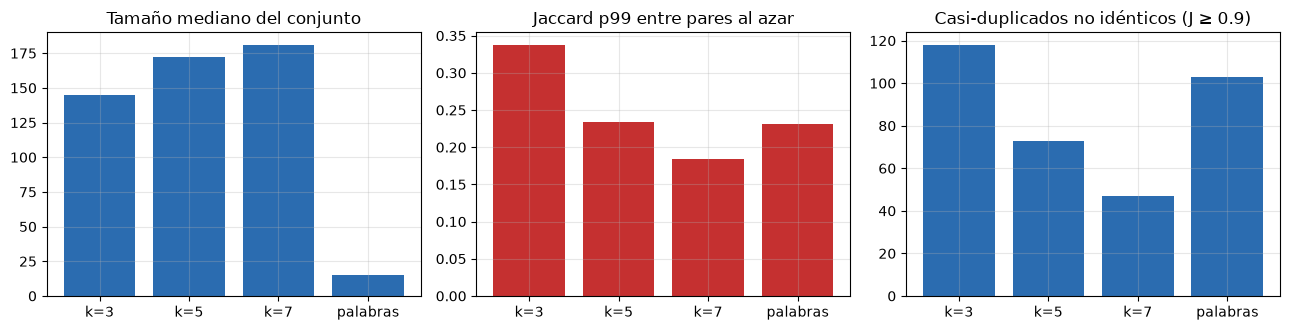

In [9]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
x = representacion["representacion"]
ax[0].bar(x, representacion["tamano_mediano"], color="#2b6cb0"); ax[0].set_title("Tamaño mediano del conjunto")
ax[1].bar(x, representacion["azar_p99"], color="#c53030"); ax[1].set_title("Jaccard p99 entre pares al azar")
ax[2].bar(x, representacion["ventana_no_identicos_ge_umbral"], color="#2b6cb0")
ax[2].set_title(f"Casi-duplicados no idénticos (J ≥ {UMBRAL})")
mostrar_fig("representacion")

- k=3 se parece demasiado al azar (Jaccard medio 0.14, p99 0.34): trigramas comunes como "cio", "ade" aparecen en casi todo

- k=7 casi no da similitud falsa (p99 0.18), pero detecta 36% menos casi-duplicados no idénticos que k=5 (47 vs 73)

- Las palabras (`tokens`) detectan más casi-duplicados (103), pero varios son falsos: "alimentos **con** ficha técnica" vs "**sin** ficha técnica" o la resolución "000017" vs "000016" quedan con Jaccard 1, porque el KDD quita stopwords y dígitos

- k=5 conserva esas diferencias y tolera errores de tipeo ("bachilller" vs "bachiller", Jaccard 0.90; con palabras, 0.67)

- Se mantiene **k=5**: equilibrio entre similitud falsa y casi-duplicados detectados

### 3. Coeficientes

`T` pares `(a, b)` generados con `SEED`, uno por función hash

In [10]:
A_COEF, B_COEF = generar_coeficientes()
print(f"t = {T} | p = {P}")
print("a[:5] =", A_COEF[:5].tolist(), "| b[:5] =", B_COEF[:5].tolist())

t = 100 | p = 2147483647
a[:5] = [191664964, 1662057957, 1405681632, 942484272, 929893138] | b[:5] = [1788288545, 429299595, 1728507682, 15810353, 1711206423]


### 4. Escritura de firmas

- Se calculan una sola vez para los 3 años y se escriben en `temp/a_minhash/firmas`, particionadas por `anio`/`mes`

- Si ya existen se reutilizan (`RECALCULAR = True` para rehacerlas)

In [11]:
RECALCULAR = False         # reutiliza las firmas si ya existen (1–2 min); True para rehacerlas

if RECALCULAR or not firmas_dir.exists():
    t0 = time.time()
    firmas = firmar(codificar_shingles(procesos.select("ocid", "entidad", "fecha", "anio", "mes", "shingles")), A_COEF, B_COEF)
    (firmas.select("ocid", "entidad", "fecha", "firma", "anio", "mes")
           .write.mode("overwrite").partitionBy("anio", "mes").parquet(str(firmas_dir)))
    print(f"Firmas guardadas en {time.time() - t0:,.0f} s")
else:
    print("Firmas ya existen; se reutilizan")

firmas = spark.read.parquet(str(firmas_dir))

Firmas guardadas en 130 s


#### a. Verificación

Mismo nº de filas que `data/final/`, largo `T`, sin nulos y mismas particiones

In [12]:
n_firmas = firmas.count()
chk = firmas.select(F.min(F.size("firma")).alias("lmin"), F.max(F.size("firma")).alias("lmax"),
                    F.sum(F.col("firma").isNull().cast("int")).alias("nulos")).first()
mb = sum(f.stat().st_size for f in firmas_dir.rglob("*.parquet")) / 1024**2
print(f"Firmas: {n_firmas:,} (procesos: {N:,}) | largo {chk['lmin']}–{chk['lmax']} | nulos {chk['nulos']} | {mb:,.1f} MB | "
      f"{len(list(firmas_dir.glob('anio=*/mes=*')))} particiones")
assert n_firmas == N and chk["lmin"] == T == chk["lmax"] and chk["nulos"] == 0

firmas.printSchema()
firmas.select("ocid", F.slice("firma", 1, 5).alias("firma (5 primeros)")).show(3, truncate=False)

Firmas: 235,954 (procesos: 235,954) | largo 100–100 | nulos 0 | 66.8 MB | 36 particiones
root
 |-- ocid: string (nullable = true)
 |-- entidad: string (nullable = true)
 |-- fecha: timestamp (nullable = true)
 |-- firma: array (nullable = true)
 |    |-- element: long (containsNull = true)
 |-- anio: integer (nullable = true)
 |-- mes: integer (nullable = true)

+---------------------------+------------------------------------------------+
|ocid                       |firma (5 primeros)                              |
+---------------------------+------------------------------------------------+
|ocds-dgv273-seacev3-1085359|[35193738, 81193696, 4662968, 13642528, 768568] |
|ocds-dgv273-seacev3-1090383|[17645537, 6102038, 6907553, 1162651, 2656992]  |
|ocds-dgv273-seacev3-1092010|[21155817, 28620693, 912678, 20127984, 19472152]|
+---------------------------+------------------------------------------------+
only showing top 3 rows



### 5. MinHash vs. Jaccard

Como en lab3.1: muestra de pares de la misma entidad, Jaccard exacto vs. estimado por la firma. Error teórico `1/(2√T) = 0.05`

Pares: 2,000 | MAE = 0.0314 | teórico 1/(2√t) = 0.0500


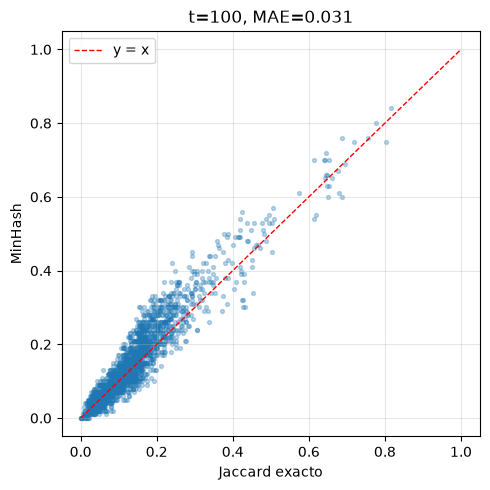

In [13]:
# ~3,000 procesos al azar → pares de la misma entidad; 2,000 pares bastan para estimar el MAE sin un join pesado
muestra = (procesos.join(firmas.select("ocid", "firma"), "ocid").select("ocid", "entidad", "shingles", "firma")
                   .sample(fraction=min(1.0, 3000 / N), seed=SEED))
a, b = muestra.alias("a"), muestra.alias("b")
eval_pd = (a.join(b, (F.col("a.entidad") == F.col("b.entidad")) & (F.col("a.ocid") < F.col("b.ocid")))
            .select(jaccard_exacto(F.col("a.shingles"), F.col("b.shingles")).alias("jaccard"),
                    minhash_sim(F.col("a.firma"), F.col("b.firma")).alias("minhash"))
            .limit(2000).toPandas())
mae = (eval_pd["jaccard"] - eval_pd["minhash"]).abs().mean()
print(f"Pares: {len(eval_pd):,} | MAE = {mae:.4f} | teórico 1/(2√t) = {1 / (2 * np.sqrt(T)):.4f}")

fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(eval_pd["jaccard"], eval_pd["minhash"], s=8, alpha=.3)
ax.plot([0, 1], [0, 1], "r--", lw=1, label="y = x")
ax.set_xlabel("Jaccard exacto"); ax.set_ylabel("MinHash"); ax.set_title(f"t={T}, MAE={mae:.3f}"); ax.legend()
mostrar_fig("minhash_vs_jaccard")

- 235,954 firmas en 1–2 min, una por proceso, sin nulos

- MAE = 0.031 frente al Jaccard exacto, por debajo del error teórico de 0.05 con `T = 100`

- Los puntos caen sobre la diagonal: la firma de 100 enteros reemplaza al conjunto de shingles para estimar Jaccard

### 6. Escritura de resultados

- Las firmas ya están en `temp/a_minhash/firmas` (insumo de `b`, `c` y `d`)

- Tablas en `temp/a_minhash/tablas` (parquet) y `web/` (json)

In [14]:
resumen = pd.DataFrame([{"procesos": N, "T": T, "mae_minhash": round(mae, 4), "error_teorico": round(1 / (2 * np.sqrt(T)), 4)}])
tablas = {"representacion": representacion, "minhash_vs_jaccard": eval_pd.round(4), "resumen": resumen}
escritos = {nombre: guardar_tabla(df, nombre) for nombre, df in tablas.items()}
print(f"Escrito en temp/a_minhash/: {', '.join(escritos)}")

Escrito en temp/a_minhash/: representacion, minhash_vs_jaccard, resumen


#### a. Verificación

In [15]:
for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 3 tablas (parquet + json) | 2 figuras: minhash_vs_jaccard, representacion


---
### 7. Cerrar sesión

In [16]:
spark.stop()